# Clustering Sintético y Evaluación con MLflow

En este notebook se generarán datos sintéticos con distintos clusters y se evaluarán dos algoritmos de clustering:

- KMeans
- KMedoids

Los resultados de cada entrenamiento se almacenarán utilizando **MLflow** para poder comparar distintos valores de \(K\).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn_extra.cluster import KMedoids

import mlflow
import mlflow.sklearn

/Users/victor.borrayo/Desktop/Prueba/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generación de clusters sintéticos

In [3]:
def generate_clusters(
    n_clusters=4,
    points_per_cluster=300,
    random_state=None
):

    rng = np.random.default_rng(random_state)

    X_list = []
    labels = []

    cluster_params = []

    for i in range(n_clusters):

        mean = rng.uniform(-10, 10, size=2)
        std = rng.uniform(0.5, 2.5)

        points = rng.normal(
            loc=mean,
            scale=std,
            size=(points_per_cluster, 2)
        )

        X_list.append(points)
        labels.extend([i] * points_per_cluster)

        cluster_params.append({
            "cluster": i,
            "mean_x": mean[0],
            "mean_y": mean[1],
            "std": std
        })

    X = np.vstack(X_list)
    y = np.array(labels)

    df = pd.DataFrame(X, columns=["x1", "x2"])
    df["cluster_true"] = y

    params_df = pd.DataFrame(cluster_params)

    return df, params_df

In [4]:
df, cluster_params = generate_clusters(
    n_clusters=5,
    points_per_cluster=400,
    random_state=42
)

df.head()

,x1,x2,cluster_true
0,7.564537,-5.548258,0
1,2.591934,-0.938984,0
2,4.777949,-1.259683,0
3,3.587756,0.727366,0
4,7.203638,-1.076028,0


In [5]:
cluster_params

,cluster,mean_x,mean_y,std
0,0,5.479121,-1.222431,2.217196
1,1,3.552415,4.515393,1.633876
2,2,-4.211406,5.921209,2.315210
3,3,3.581031,-8.191838,1.684550
4,4,-1.578902,-8.196560,1.366748


## Visualización de los datos

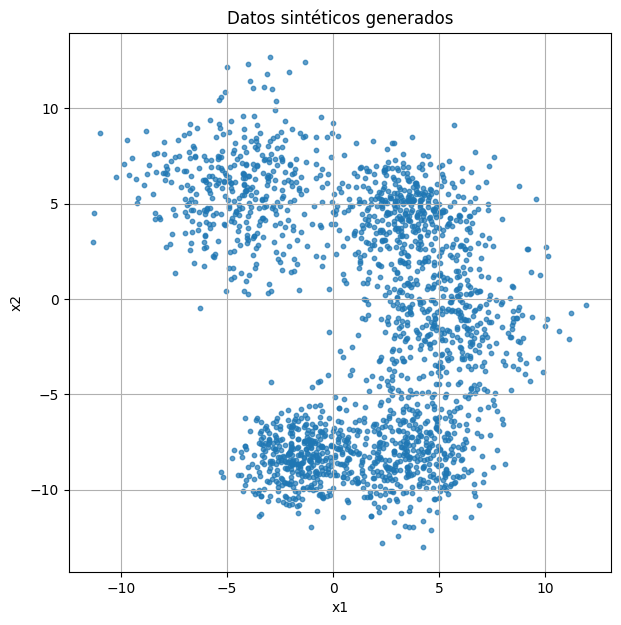

In [6]:
plt.figure(figsize=(7,7))

plt.scatter(
    df["x1"],
    df["x2"],
    s=10,
    alpha=0.7
)

plt.title("Datos sintéticos generados")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)

plt.show()

## Configuración de MLflow

In [9]:
project_root = Path("../")

mlruns_path = "../mlruns"

mlflow.set_tracking_uri(mlruns_path)

mlflow.set_experiment("clustering_experiments")

print("MLflow tracking URI:", mlruns_path)

/Users/victor.borrayo/Desktop/Prueba/.venv/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/12 20:36:46 INFO mlflow.tracking.fluent: Experiment with name 'clustering_experiments' does not exist. Creating a new experiment.


MLflow tracking URI: ../mlruns


## Función para entrenar y registrar experimentos

In [10]:
def run_clustering_experiment(
    X,
    k_values,
    algorithm="kmeans"
):

    results = []

    for k in k_values:

        with mlflow.start_run(run_name=f"{algorithm}_k{k}"):

            if algorithm == "kmeans":

                model = KMeans(
                    n_clusters=k,
                    random_state=42
                )

            elif algorithm == "kmedoids":

                model = KMedoids(
                    n_clusters=k,
                    random_state=42
                )

            else:
                raise ValueError("Algoritmo no soportado")

            labels = model.fit_predict(X)

            silhouette = silhouette_score(X, labels)

            mlflow.log_param("algorithm", algorithm)
            mlflow.log_param("k", k)

            mlflow.log_metric("silhouette_score", silhouette)

            mlflow.sklearn.log_model(
                model,
                artifact_path="model"
            )

            results.append({
                "algorithm": algorithm,
                "k": k,
                "silhouette": silhouette
            })

    return pd.DataFrame(results)

## Selección de variables sin etiqueta

In [11]:
X = df[["x1", "x2"]].values

In [12]:
k_values = list(range(2,10))

## Experimentos con KMeans

In [13]:
results_kmeans = run_clustering_experiment(
    X,
    k_values,
    algorithm="kmeans"
)

results_kmeans

2026/03/12 20:38:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 20:38:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/12 20:39:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 20:39:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

,algorithm,k,silhouette
0,kmeans,2,0.513604
1,kmeans,3,0.532511
2,kmeans,4,0.487063
3,kmeans,5,0.484419
4,kmeans,6,0.431928
5,kmeans,7,0.446531
6,kmeans,8,0.391966
7,kmeans,9,0.401515


## Experimentos con KMedoids

In [14]:
results_kmedoids = run_clustering_experiment(
    X,
    k_values,
    algorithm="kmedoids"
)

results_kmedoids

2026/03/12 20:39:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 20:39:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/12 20:39:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 20:39:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

,algorithm,k,silhouette
0,kmedoids,2,0.512520
1,kmedoids,3,0.532548
2,kmedoids,4,0.487302
3,kmedoids,5,0.484616
4,kmedoids,6,0.455843
5,kmedoids,7,0.408878
6,kmedoids,8,0.414227
7,kmedoids,9,0.381810
